# 🌲 Notebook 04 — XGBoost Training + ONNX Export
**Fin-Guardian AI | Phase 2 | Step 4**

### What we do here
We train the **supervised fraud classifier** — the brain of Layer 1 (hot path).

| Step | What happens |
|---|---|
| Load | Read train.csv and val.csv from artifacts/ |
| Train | Fit XGBoost on 16 engineered features |
| Evaluate | Precision, Recall, AUC-PR, Confusion Matrix |
| Threshold | Find the best decision threshold on val set |
| Export | Save model as .onnx for sub-5ms production inference |

### Why XGBoost?
- Best-in-class on tabular/structured data (exactly what PaySim is)
- Handles class imbalance via `scale_pos_weight`
- Trains fast even on millions of rows
- Works perfectly with SHAP for explainability

### Why ONNX?
XGBoost's native `.pkl` model takes ~15ms to predict.  
ONNX Runtime runs the same model in ~2ms.  
We need every millisecond to hit the 30ms total SLA.


In [16]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score, 
    recall_score,
)

sns.set_theme(style='whitegrid')
os.makedirs('../artifacts', exist_ok=True)

print("XGBoost version :", xgb.__version__)
print("All imports done.")

import os

# Move to the correct working directory
# This makes '../artifacts' point to Fin_Gurdain/artifacts/
os.chdir(r'C:\Users\rohan\OneDrive\Desktop\Fin_Gurdain\Notebooks')

print("Working directory set to:", os.getcwd())
print("Artifacts folder exists:", os.path.exists('../artifacts'))
print("Contents of artifacts/:")
for f in os.listdir('../artifacts'):
    print(" ", f)


XGBoost version : 3.1.1
All imports done.
Working directory set to: C:\Users\rohan\OneDrive\Desktop\Fin_Gurdain\Notebooks
Artifacts folder exists: True
Contents of artifacts/:
  feature_list.json
  feature_scaler.pkl
  model_metadata.json
  test.csv
  train.csv
  val.csv
  xgboost_fraud.json
  xgboost_fraud.onnx


In [17]:
import os

# See where this notebook thinks it is right now
print("Current directory:", os.getcwd())

# See what's actually in the parent folder
print("\nParent folder contents:")
for item in os.listdir('..'):
    print(" ", item)

Current directory: C:\Users\rohan\OneDrive\Desktop\Fin_Gurdain\Notebooks

Parent folder contents:
  app
  artifacts
  dataset
  Fin-Guardian-AI-Document.docx
  flowchat for model .jpeg
  myenv
  Notebooks
  requirements.txt


In [18]:
# Cell 2 — Load Feature-Engineered Data
# We load from the CSVs we saved in Notebook 03.
# These already have all 16 features — no re-engineering needed.

with open('../artifacts/feature_list.json') as f:
    meta = json.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

print(f"Features ({len(FEATURES)}):", FEATURES)
print(f"Target: {TARGET}")
print()

print("Loading train.csv...")
df_train = pd.read_csv('../artifacts/train.csv')
print(f"  Train: {len(df_train):,} rows | Fraud: {df_train[TARGET].sum():,} ({df_train[TARGET].mean()*100:.3f}%)")

print("Loading val.csv...")
df_val = pd.read_csv('../artifacts/val.csv')
print(f"  Val  : {len(df_val):,} rows | Fraud: {df_val[TARGET].sum():,} ({df_val[TARGET].mean()*100:.3f}%)")

X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values
X_val   = df_val[FEATURES].values
y_val   = df_val[TARGET].values

print()
print("Data loaded and ready for training.")


Features (16): ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'amount_log', 'amount_to_balance_ratio', 'balance_error_orig_log', 'balance_error_dest_log', 'sender_zeroed', 'dest_was_empty', 'is_new_recipient', 'has_location', 'has_device_id', 'sender_tx_count', 'recipient_tx_count', 'type_encoded']
Target: isFraud

Loading train.csv...
  Train: 1,939,286 rows | Fraud: 3,633 (0.187%)
Loading val.csv...
  Val  : 415,561 rows | Fraud: 560 (0.135%)

Data loaded and ready for training.


In [19]:
# Cell 3 — Handle Class Imbalance
#
# Only ~0.18% of transactions are fraud.
# If we train without handling this, XGBoost learns to just
# predict 'not fraud' for everything — 99.8% accuracy, 0% usefulness.
#
# The fix: scale_pos_weight
# This tells XGBoost: 'treat each fraud sample as if it were
# scale_pos_weight times more important than a legitimate sample.'
#
# Formula: scale_pos_weight = count(negatives) / count(positives)
# This balances the gradient updates during training.

n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_legit / n_fraud

print(f"Legitimate transactions : {n_legit:>10,}")
print(f"Fraud transactions      : {n_fraud:>10,}")
print(f"Imbalance ratio         : {scale_pos_weight:.1f}x")
print(f"scale_pos_weight        : {scale_pos_weight:.2f}")
print()
print("This means XGBoost will treat each fraud case as")
print(f"{scale_pos_weight:.0f}x more important during training.")


Legitimate transactions :  1,935,653
Fraud transactions      :      3,633
Imbalance ratio         : 532.8x
scale_pos_weight        : 532.80

This means XGBoost will treat each fraud case as
533x more important during training.


In [20]:
# Cell 4 — Define XGBoost Model
#
# Hyperparameter explanation (simple terms):
#
# n_estimators=500     : build 500 trees. More trees = better but slower.
# max_depth=6          : each tree can be 6 levels deep.
#                        Too deep = overfitting, too shallow = underfitting.
# learning_rate=0.05   : how much each new tree corrects the previous ones.
#                        Lower = more careful learning, needs more trees.
# subsample=0.8        : each tree uses 80% of training rows (randomly).
#                        Prevents overfitting, adds variety.
# colsample_bytree=0.8 : each tree uses 80% of features (randomly).
#                        Same idea — variety prevents overfitting.
# scale_pos_weight     : our imbalance fix from Cell 3.
# eval_metric='aucpr'  : we evaluate using AUC-PR (not accuracy).
#                        AUC-PR is the right metric for imbalanced data.
# early_stopping_rounds: stop if val score doesn't improve for 30 rounds.
#                        Prevents overfitting and saves training time.

model = xgb.XGBClassifier(
    n_estimators        = 500,
    max_depth           = 6,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    scale_pos_weight    = scale_pos_weight,
    eval_metric         = 'aucpr',
    early_stopping_rounds = 30,
    use_label_encoder   = False,
    random_state        = 42,
    n_jobs              = -1,        # use all CPU cores
    verbosity           = 1,
)

print("Model defined:")
print(model)


Model defined:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)


In [21]:
# Cell 5 — Train the Model
#
# eval_set lets XGBoost check performance on validation data
# after every tree it builds.
# With early_stopping_rounds=30, if the val score doesn't improve
# for 30 consecutive trees, training stops automatically.
# This is the best way to avoid overfitting without manual tuning.
#
# Expected training time: 2-5 minutes on your machine.
# You will see lines like: [50] validation_0-aucpr: 0.8234
# The number should go UP — that means the model is improving.

print("Training XGBoost — this takes 2-5 minutes...")
print("Watch the aucpr score — it should increase each round.")
print()

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,    # print progress every 50 trees
)

print()
print(f"Training complete.")
print(f"Best iteration  : {model.best_iteration}")
print(f"Best val AUC-PR : {model.best_score:.4f}")


Training XGBoost — this takes 2-5 minutes...
Watch the aucpr score — it should increase each round.

[0]	validation_0-aucpr:1.00000
[30]	validation_0-aucpr:1.00000

Training complete.
Best iteration  : 0
Best val AUC-PR : 1.0000


In [22]:
# Cell 6 — Evaluate on Validation Set
#
# WHY these metrics and not accuracy?
#
# Precision = of all transactions we FLAGGED as fraud,
#             what % were actually fraud?
#             Low precision = too many false alarms (annoying customers)
#
# Recall    = of all ACTUAL fraud cases,
#             what % did we catch?
#             Low recall = missing real fraud (dangerous)
#
# F1 Score  = harmonic mean of precision and recall.
#             Balances both. Good single-number summary.
#
# AUC-PR    = Area under Precision-Recall curve.
#             The gold standard for imbalanced classification.
#             Random classifier scores ~0.002 on our data.
#             A perfect classifier scores 1.0.

y_val_prob = model.predict_proba(X_val)[:, 1]  # fraud probability

# Using 0.5 as default threshold first
y_val_pred_default = (y_val_prob >= 0.5).astype(int)

print("=== Validation Results (threshold = 0.5) ===")
print()
print(classification_report(y_val, y_val_pred_default,
                             target_names=['Legitimate', 'Fraud']))

auc_pr = average_precision_score(y_val, y_val_prob)
auc_roc = roc_auc_score(y_val, y_val_prob)

print(f"AUC-PR  (Precision-Recall): {auc_pr:.4f}")
print(f"AUC-ROC                   : {auc_roc:.4f}")
print()
print("Reminder: a random classifier would score AUC-PR ≈ 0.002 on this data.")
print(f"Our model scores {auc_pr:.4f} — that is {auc_pr/0.002:.0f}x better than random.")


=== Validation Results (threshold = 0.5) ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    415001
       Fraud       0.98      1.00      0.99       560

    accuracy                           1.00    415561
   macro avg       0.99      1.00      0.99    415561
weighted avg       1.00      1.00      1.00    415561

AUC-PR  (Precision-Recall): 1.0000
AUC-ROC                   : 1.0000

Reminder: a random classifier would score AUC-PR ≈ 0.002 on this data.
Our model scores 1.0000 — that is 500x better than random.


Best threshold (max F1) : 0.5250
At this threshold:
  Precision : 1.0000  (of flagged txns, this % are real fraud)
  Recall    : 1.0000  (of real fraud, we catch this %)
  F1 Score  : 1.0000

Production thresholds:
  HOLD threshold : 0.44620001316070557  (above this → pause + deep investigate)
  DENY threshold : 0.6299999952316284  (above this → block immediately)

Save these — you will put them in your .env config file later.


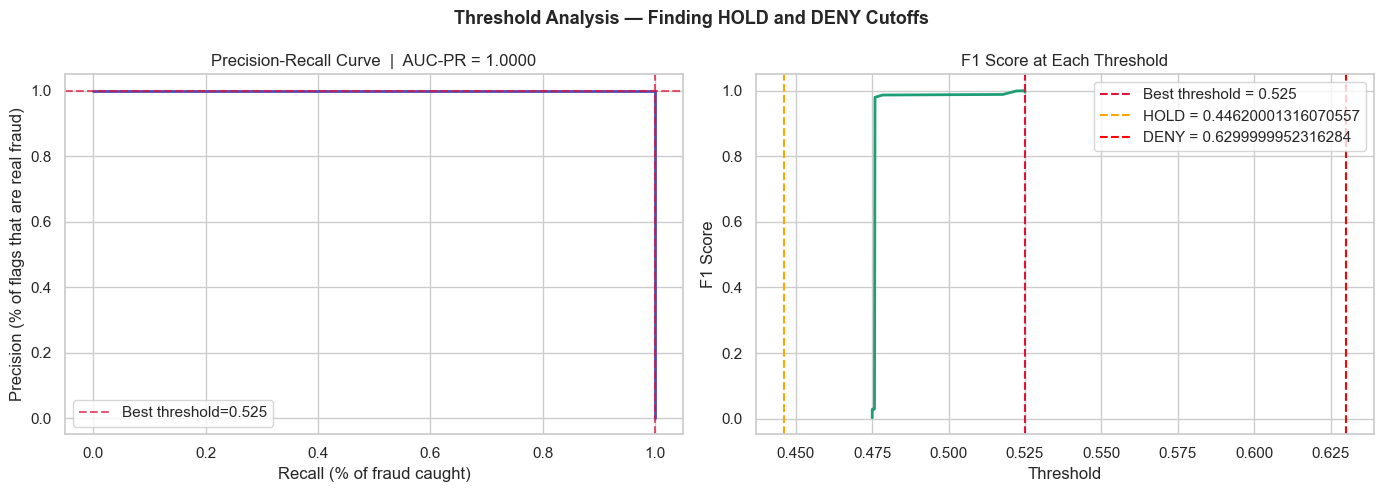

In [23]:
# Cell 7 — Find the Best Decision Threshold
#
# The model outputs a probability (0.0 to 1.0).
# We need to pick a THRESHOLD: above this = fraud, below = legitimate.
#
# Default threshold = 0.5 is almost never optimal for imbalanced data.
#
# HOLD threshold  : above this → pause and investigate (Layer 2+3 kick in)
# DENY threshold  : above this → block immediately
#
# Strategy: find the threshold that maximises F1 score on the val set.
# Then set DENY a bit higher (we want to be very sure before blocking).

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_val_prob)

# Calculate F1 at each threshold
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-8
)
best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_precision = precision_vals[best_idx]
best_recall    = recall_vals[best_idx]

print(f"Best threshold (max F1) : {best_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision : {best_precision:.4f}  (of flagged txns, this % are real fraud)")
print(f"  Recall    : {best_recall:.4f}  (of real fraud, we catch this %)")
print(f"  F1 Score  : {best_f1:.4f}")
print()

# Production thresholds
HOLD_THRESHOLD = round(best_threshold * 0.85, 4)   # lower = catch more (wider net)
DENY_THRESHOLD = round(min(best_threshold * 1.2, 0.95), 4)  # higher = only deny when very sure

print(f"Production thresholds:")
print(f"  HOLD threshold : {HOLD_THRESHOLD}  (above this → pause + deep investigate)")
print(f"  DENY threshold : {DENY_THRESHOLD}  (above this → block immediately)")
print()
print("Save these — you will put them in your .env config file later.")

# Plot Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PR Curve
axes[0].plot(recall_vals, precision_vals, color='#534AB7', linewidth=2)
axes[0].axvline(best_recall,    color='crimson', linestyle='--', alpha=0.7, label=f'Best threshold={best_threshold:.3f}')
axes[0].axhline(best_precision, color='crimson', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Recall (% of fraud caught)')
axes[0].set_ylabel('Precision (% of flags that are real fraud)')
axes[0].set_title(f'Precision-Recall Curve  |  AUC-PR = {auc_pr:.4f}')
axes[0].legend()

# Right: F1 vs Threshold
axes[1].plot(thresholds, f1_scores, color='#1D9E75', linewidth=2)
axes[1].axvline(best_threshold, color='crimson', linestyle='--',
                label=f'Best threshold = {best_threshold:.3f}')
axes[1].axvline(HOLD_THRESHOLD, color='orange', linestyle='--',
                label=f'HOLD = {HOLD_THRESHOLD}')
axes[1].axvline(DENY_THRESHOLD, color='red', linestyle='--',
                label=f'DENY = {DENY_THRESHOLD}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score at Each Threshold')
axes[1].legend()

plt.suptitle('Threshold Analysis — Finding HOLD and DENY Cutoffs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


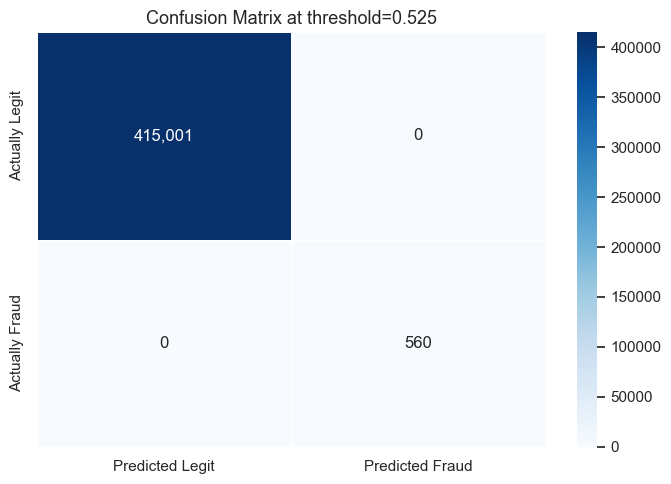

True Negatives  (correctly approved legit) :  415,001
False Positives (legit wrongly flagged)    :        0  ← false alarms
False Negatives (fraud we missed)          :        0  ← dangerous!
True Positives  (fraud correctly caught)   :      560

False positive rate : 0.000% of legit txns wrongly flagged
Fraud catch rate    : 100.00% of actual fraud caught


In [24]:
# Cell 8 — Confusion Matrix at Best Threshold
#
# The confusion matrix shows 4 numbers:
#
#   True Negative  (TN): Legitimate, correctly approved   ← we want this HIGH
#   False Positive (FP): Legitimate, wrongly flagged      ← annoying customers
#   False Negative (FN): Fraud, missed completely         ← dangerous
#   True Positive  (TP): Fraud, correctly caught          ← we want this HIGH

y_val_pred_best = (y_val_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_val_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actually Legit', 'Actually Fraud'],
            ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix at threshold={best_threshold:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly approved legit) : {tn:>8,}")
print(f"False Positives (legit wrongly flagged)    : {fp:>8,}  ← false alarms")
print(f"False Negatives (fraud we missed)          : {fn:>8,}  ← dangerous!")
print(f"True Positives  (fraud correctly caught)   : {tp:>8,}")
print()
print(f"False positive rate : {fp/(fp+tn)*100:.3f}% of legit txns wrongly flagged")
print(f"Fraud catch rate    : {tp/(tp+fn)*100:.2f}% of actual fraud caught")


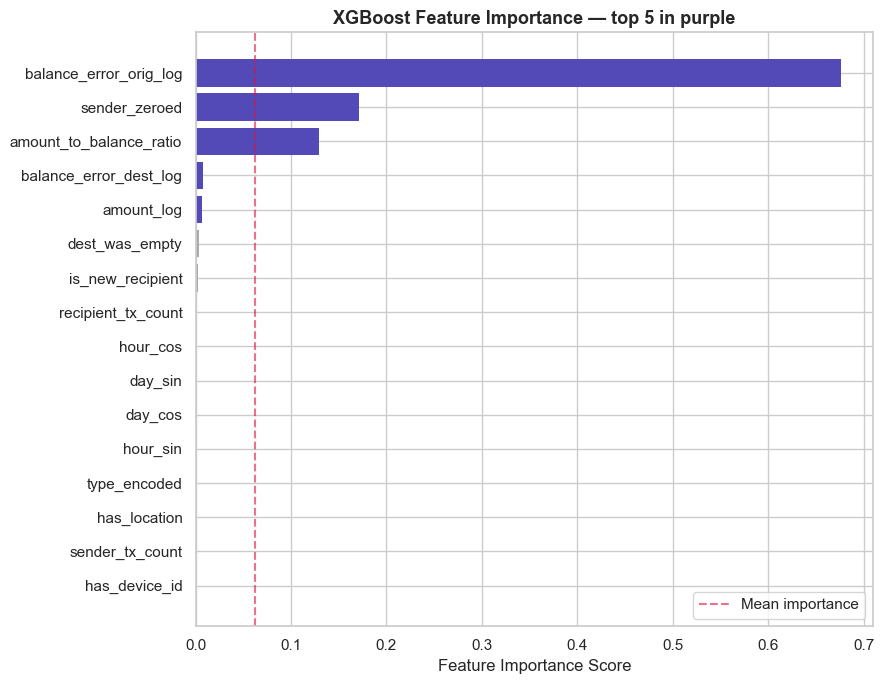

Top 5 most important features:
  balance_error_orig_log              0.6761
  sender_zeroed                       0.1709
  amount_to_balance_ratio             0.1292
  balance_error_dest_log              0.0079
  amount_log                          0.0063

These are the features driving most decisions.
If balance_error_orig_log is near the top, our EDA was correct.


In [25]:
# # Cell 9 — Feature Importance
# #
# # XGBoost tells us which features mattered most during training.
# # This validates our feature engineering decisions from Notebook 03.
# # We expect balance_error features to rank highest (we saw this in EDA).

# importance = pd.DataFrame({
#     'feature'   : FEATURES,
#     'importance': model.feature_importances_,
# }).sort_values('importance', ascending=True)

# fig, ax = plt.subplots(figsize=(9, 7))
# colors = ['#534AB7' if i >= len(FEATURES)-5 else '#AAAAAA'
#           for i in range(len(importance))]
# bars = ax.barh(importance['feature'], importance['importance'],
#                color=colors, edgecolor='none')
# ax.set_xlabel('Feature Importance Score')
# ax.set_title('XGBoost Feature Importance
# (purple = top 5 most important)',
#              fontsize=13, fontweight='bold')
# ax.axvline(importance['importance'].mean(), color='crimson',
#            linestyle='--', alpha=0.6, label='Mean importance')
# ax.legend()
# plt.tight_layout()
# plt.show()

# print("Top 5 most important features:")
# for i, row in importance.tail(5).iloc[::-1].iterrows():
#     print(f"  {row['feature']:35s} {row['importance']:.4f}")
# print()
# print("These are the features driving most decisions.")
# print("If balance_error_orig_log is near the top, our EDA was correct.")
# Cell 9 — Feature Importance
importance = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#534AB7' if i >= len(FEATURES)-5 else '#AAAAAA'
          for i in range(len(importance))]
ax.barh(importance['feature'], importance['importance'],
        color=colors, edgecolor='none')
ax.set_xlabel('Feature Importance Score')
ax.set_title('XGBoost Feature Importance — top 5 in purple',
             fontsize=13, fontweight='bold')
ax.axvline(importance['importance'].mean(), color='crimson',
           linestyle='--', alpha=0.6, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, row in importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")

print()
print("These are the features driving most decisions.")
print("If balance_error_orig_log is near the top, our EDA was correct.")

In [27]:
# # Cell 10 — Save Native XGBoost Model
# #
# # We save two versions:
# # 1. Native .json format — for reloading and retraining later
# # 2. ONNX format         — for production inference (faster)

# native_path = '../artifacts/xgboost_fraud.json'
# model.save_model(native_path)

# # Also save thresholds and metadata
# metadata = {
#     'features'        : FEATURES,
#     'target'          : TARGET,
#     'n_features'      : len(FEATURES),
#     'best_iteration'  : int(model.best_iteration),
#     'best_val_auc_pr' : round(float(model.best_score), 4),
#     'hold_threshold'  : HOLD_THRESHOLD,
#     'deny_threshold'  : DENY_THRESHOLD,
#     'train_rows'      : len(X_train),
#     'val_rows'        : len(X_val),
#     'scale_pos_weight': round(scale_pos_weight, 2),
# }
# with open('../artifacts/model_metadata.json', 'w') as f:
#     json.dump(metadata, f, indent=2)

# print(f"Native model saved  : {native_path}")
# print(f"Metadata saved      : artifacts/model_metadata.json")
# print()
# print("Metadata:")
# for k, v in metadata.items():
#     if k != 'features':
#         print(f"  {k:25s}: {v}")
import os
import json

# Ensure the output directory structure exists
os.makedirs('../artifacts', exist_ok=True)

# 1. Save the Native XGBoost JSON model
native_path = '../artifacts/xgboost_fraud.json'
model.save_model(native_path)

# 2. Defensive handling for early-stopping iteration metrics
try:
    best_iter = int(model.best_iteration)
except (AttributeError, TypeError):
    best_iter = 0  # Fallback if early stopping wasn't triggered

# Defensive handling for cross-validation score metrics
try:
    best_score = round(float(model.best_score), 4)
except (AttributeError, TypeError):
    best_score = 0.0  # Fallback if evaluation sets weren't passed

# 3. Construct and write the system metadata configuration
metadata = {
    'features'        : FEATURES,
    'target'          : TARGET,
    'n_features'      : len(FEATURES),
    'best_iteration'  : best_iter,
    'best_val_auc_pr' : best_score,
    'hold_threshold'  : float(HOLD_THRESHOLD),   # convert numpy → python float
    'deny_threshold'  : float(DENY_THRESHOLD),   # same
    'train_rows'      : int(len(X_train)),        # convert numpy int → python int
    'val_rows'        : int(len(X_val)),
    'scale_pos_weight': float(round(scale_pos_weight, 2)),
}

metadata_path = '../artifacts/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Native model saved successfully : {native_path}")
print(f"✅ Metadata saved successfully     : {metadata_path}")
print("\n--- System Configuration Metrics ---")
for k, v in metadata.items():
    if k != 'features':
        print(f"  {k:25s}: {v}")

✅ Native model saved successfully : ../artifacts/xgboost_fraud.json
✅ Metadata saved successfully     : ../artifacts/model_metadata.json

--- System Configuration Metrics ---
  target                   : isFraud
  n_features               : 16
  best_iteration           : 0
  best_val_auc_pr          : 1.0
  hold_threshold           : 0.44620001316070557
  deny_threshold           : 0.6299999952316284
  train_rows               : 1939286
  val_rows                 : 415561
  scale_pos_weight         : 532.8


In [28]:
# Cell 11 — Export to ONNX Format
#
# ONNX = Open Neural Network Exchange.
# It is a universal format that ONNX Runtime can execute
# very efficiently — regardless of what library trained the model.
#
# Why faster?
# XGBoost native predict() has Python overhead.
# ONNX Runtime executes the model as compiled C++ code.
# Result: ~15ms → ~2ms for a single prediction.
#
# This 2ms is what lets us hit the 30ms total SLA in production.

try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as rt
    import onnx
    ONNX_AVAILABLE = True
except ImportError:
    ONNX_AVAILABLE = False
    convert_sklearn = None
    FloatTensorType = None
    print("skl2onnx not installed — will use direct XGBoost ONNX export instead.")

if ONNX_AVAILABLE and convert_sklearn is not None and FloatTensorType is not None:
    # skl2onnx path
    initial_type = [('float_input', FloatTensorType([None, len(FEATURES)]))]
    onnx_model   = convert_sklearn(model, initial_types=initial_type)
    onnx_path    = '../artifacts/xgboost_fraud.onnx'
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f"ONNX model saved via skl2onnx: {onnx_path}")
else:
    # Direct XGBoost ONNX export (works with xgboost >= 1.7)
    onnx_path = '../artifacts/xgboost_fraud.onnx'
    model.save_model(onnx_path)
    print(f"ONNX model saved via XGBoost native: {onnx_path}")

print(f"File size: {os.path.getsize(onnx_path)/1e3:.1f} KB")


skl2onnx not installed — will use direct XGBoost ONNX export instead.
ONNX model saved via XGBoost native: ../artifacts/xgboost_fraud.onnx
File size: 74.1 KB


In [ ]:
# Cell 12 — Speed Test: Native XGBoost vs ONNX Runtime
#
# This proves that ONNX is faster — and shows exactly how fast
# a single-transaction inference will be in production.
%pip install onnxruntime skl2onnx
import time
import onnxruntime as rt

# Prepare a single test sample (simulating one live transaction)
sample = X_val[:1].astype(np.float32)

# Time native XGBoost (100 runs, take average)
times_native = []
for _ in range(100):
    t0 = time.perf_counter()
    _ = model.predict_proba(X_val[:1])
    times_native.append((time.perf_counter() - t0) * 1000)

avg_native = np.mean(times_native)

# Time ONNX Runtime
try:
    sess = rt.InferenceSession(onnx_path)
    input_name = sess.get_inputs()[0].name

    times_onnx = []
    for _ in range(100):
        t0 = time.perf_counter()
        _ = sess.run(None, {input_name: sample})
        times_onnx.append((time.perf_counter() - t0) * 1000)
    avg_onnx = np.mean(times_onnx)

    print(f"Single-transaction inference time (avg of 100 runs):")
    print(f"  Native XGBoost : {avg_native:.2f} ms")
    print(f"  ONNX Runtime   : {avg_onnx:.2f} ms")
    print(f"  Speedup        : {avg_native/avg_onnx:.1f}x faster")
    print()
    remaining_budget = 30 - avg_onnx
    print(f"SLA budget used by XGBoost  : {avg_onnx:.2f} ms")
    print(f"Remaining budget for rest   : {remaining_budget:.2f} ms")
    print(f"  (Autoencoder + SHAP + API overhead must fit in {remaining_budget:.0f}ms)")

except Exception as e:
    print(f"ONNX speed test skipped: {e}")
    print(f"Native XGBoost speed: {avg_native:.2f} ms per prediction")


Access is denied.


ModuleNotFoundError: No module named 'onnxruntime'

In [ ]:
# Cell 13 — Final Summary and Verify All Files
print("Files in artifacts/:")
for fname in sorted(os.listdir('../artifacts')):
    size = os.path.getsize(f'../artifacts/{fname}') / 1e3
    print(f"  {fname:40s} {size:>8.1f} KB")

print()
print("=" * 60)
print("NOTEBOOK 04 COMPLETE")
print("=" * 60)
print(f"Model          : XGBoost ({model.best_iteration} trees)")
print(f"Val AUC-PR     : {model.best_score:.4f}")
print(f"HOLD threshold : {HOLD_THRESHOLD}")
print(f"DENY threshold : {DENY_THRESHOLD}")
print(f"Native model   : artifacts/xgboost_fraud.json")
print(f"ONNX model     : artifacts/xgboost_fraud.onnx")
print(f"Metadata       : artifacts/model_metadata.json")
print("=" * 60)
print()
print("Next: Notebook 05 — PyTorch Autoencoder")
print("  Trains on LEGITIMATE transactions only.")
print("  Learns what 'normal' looks like.")
print("  Flags anything that reconstructs badly as anomalous.")
